# ipynb/cls_compare_nofont_abla2.ipynb - 分类结果对比(消融2,无字体) / Classification compare (ablation 2, no font)

## 项目背景 / Background
分类结果对比(消融2,无字体)
Classification compare (ablation 2, no font)

## 功能模块 / Modules
- 消融2 实验的分类结果对比
- (详见各代码单元 / see code cells)

## 输入 / Inputs
- 上一阶段产物(.npy/.pt/.csv/.json)/ prior-stage outputs
- 内嵌常量与参数 / inline constants and params

## 输出 / Outputs
- 图表(内联显示) / figures (inline)
- 中间变量 / intermediate variables
- 导出文件(.png/.pdf/.csv) / exported files

## 数据流 / Data Flow
1. 加载数据 / Load data
2. 运行分析 / Run analysis
3. 渲染图表 / Render figures
4. 导出 / Export

## 相关文件 / Related Files
- 调用 / Calls: ipynb/cls_compare_nofont_abla.ipynb、3x3_2.py
- 被调用 / Called by: 报告 / 论文 / report / paper

## 使用示例 / Usage Example
- 在 JupyterLab 中打开 / open in JupyterLab
- 逐单元运行 / run cells sequentially

## 作者 / Author
项目组 / Project Team

## 版本 / Version
1.0



Warning message:
“package ‘showtext’ was built under R version 4.3.3”
Loading required package: sysfonts

Warning message:
“package ‘sysfonts’ was built under R version 4.3.3”


Loading required package: showtextdb

Warning message:
“package ‘showtextdb’ was built under R version 4.3.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘scales’ was built under R version 4.3.3”


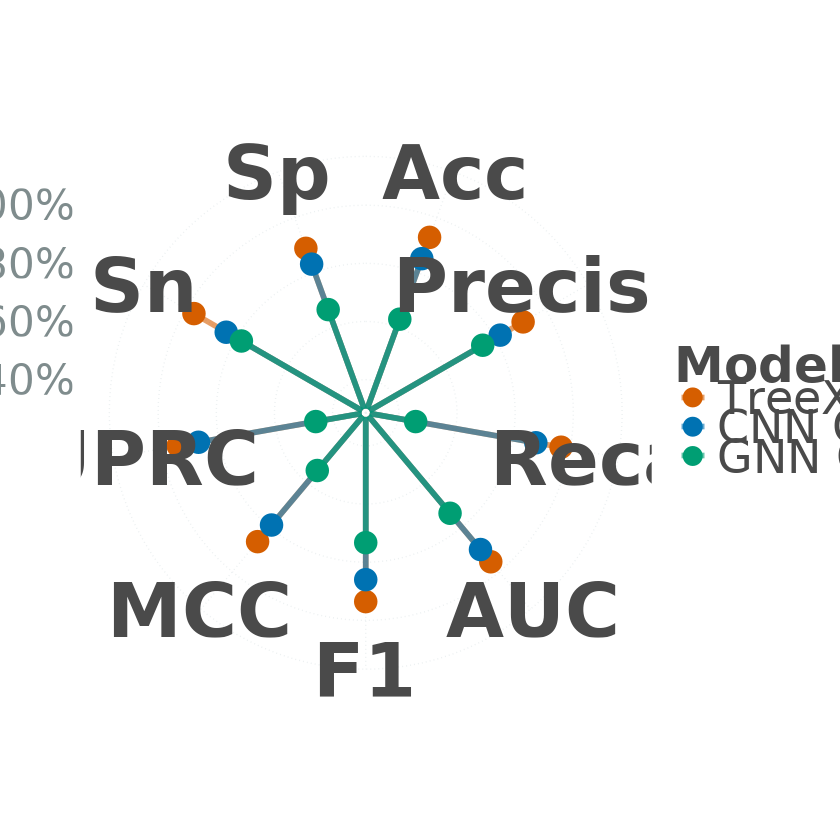

In [1]:
# 1. 安装并加载字体管理包
library(showtext)
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)

# 2. 注册 DejaVu Sans 字体
tryCatch({
  font_add("DejaVu", 
           regular = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 
           bold = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf")
  showtext_auto()
}, error = function(e) message("字体加载失败，使用默认字体"))

showtext_opts(dpi = 300)

# --- 1. 数据读取与处理 ---
# 支持两种格式：字符串路径（读取 CSV）或数值列表（直接使用）
file_list <- list(
  "TreeX" = "data/res.csv",
  "CNN Only" = c(0.85, 0.82, 0.88, 0.90, 0.86, 0.79, 0.87, 0.84, 0.83),
  "GNN Only" = c(0.6286, 0.7506, 0.4604, 0.7372, 0.7327, 0.5452, 0.4604, 0.7797, 0.6636)
)

metric_levels <- c("Acc", "Precision", "Recall", "AUC", "F1", "MCC", "AUPRC", "Sn", "Sp")

# 自动读取并计算均值（支持混合类型）
df_list <- lapply(names(file_list), function(mname) {
  input_data <- file_list[[mname]]
  
  # 判断输入类型
  if (is.character(input_data) && length(input_data) == 1) {
    # 字符串路径：读取 CSV 并计算均值
    df <- read.csv(input_data) %>%
      summarise(across(all_of(metric_levels), \(x) mean(x, na.rm = TRUE))) %>%
      mutate(Model = mname)
  } else if (is.numeric(input_data) && length(input_data) == length(metric_levels)) {
    # 数值列表：直接使用
    df <- data.frame(t(input_data)) %>%
      setNames(metric_levels) %>%
      mutate(Model = mname)
  } else {
    stop(paste("Invalid data format for model:", mname))
  }
  
  return(df)
})

# 合并数据并处理格式
plot_data <- bind_rows(df_list) %>%
  pivot_longer(cols = all_of(metric_levels), names_to = "Metric", values_to = "Value") %>%
  mutate(
    Metric = factor(Metric, levels = metric_levels),
    Model = factor(Model, levels = names(file_list))
  ) %>%
  group_by(Metric) %>%
  mutate(Rank = rank(-Value, ties.method = "first")) %>% 
  ungroup() %>%
  mutate(Rank_Factor = factor(Rank, levels = c(1, 2, 3), labels = c("1st (Best)", "2nd", "3rd")))

# 动态计算 Y 轴范围
y_min <- 0.3
y_max <- max(plot_data$Value, na.rm = TRUE) + 0.05
y_upper_limit <- 1.0

# --- 2. 定义高区分度配色方案（色盲友好） ---
contrast_colors <- c(
  "#D55E00",  # TreeX - 朱红色
  "#0072B2",  # CNN Only - 深蓝色
  "#009E73"   # GNN Only - 青绿色
)

contrast_palette <- setNames(
  contrast_colors[seq_along(file_list)], 
  names(file_list)
)

# --- 3. 径向棒棒糖图绘制 ---
p1 <- ggplot(plot_data, aes(x = Metric, y = Value, group = Model, color = Model)) +
  geom_segment(aes(x = Metric, xend = Metric, y = y_min, yend = Value), 
               linewidth = 1.2, alpha = 0.6) +
  geom_point(size = 6, shape = 16) +
  scale_color_manual(name = "Model", values = contrast_palette) +
  scale_y_continuous(
    limits = c(y_min, y_upper_limit),
    breaks = seq(0.4, 1.0, by = 0.2),
    labels = scales::percent,
    expand = expansion(mult = c(0.02, 0.1))
  ) +
  scale_x_discrete(expand = expansion(add = c(0.5, 0.5))) +
  coord_polar(theta = "x", start = 0) +
  theme_minimal() +
  theme(
    text = element_text(family = "DejaVu"),
    axis.text.x = element_text(size = 18, face = "bold", color = "#4A4A4A"),
    axis.text.y = element_text(size = 10, color = "#7F8C8D"),
    axis.title = element_blank(),
    panel.grid.major = element_line(color = "#ECF0F1", linewidth = 0.3, linetype = "dotted"),
    panel.grid.minor = element_blank(),
    panel.background = element_rect(fill = "white", color = NA),
    plot.background = element_rect(fill = "white", color = NA),
    legend.position = "right",
    legend.title = element_text(size = 12, face = "bold", color = "#4A4A4A"),
    legend.text = element_text(size = 11, color = "#4A4A4A"),
    plot.margin = margin(15, 15, 15, 15)
  ) +
  guides(
    color = guide_legend(
      override.aes = list(size = 5),
      label.theme = element_text(size = 11, family = "DejaVu"),
      order = 1,
      title.theme = element_text(size = 12, family = "DejaVu")
    )
  )

# --- 4. 保存图片 ---
ggsave("png2/cls_compare_radial_lollipop2.pdf", p1, width = 10, height = 8, dpi = 300)
print(p1)